In [17]:
#Step 1: Environment Setup & Library Imports
import string
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Download standard NLTK stopwords
nltk.download('stopwords')

sns.set_theme(style="whitegrid")
print("Environment initialized successfully.")

Environment initialized successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Initial records: 5572
Records after deduplication: 5169


,Count,Percentage (%)
label,,
ham,4516,87.37
spam,653,12.63


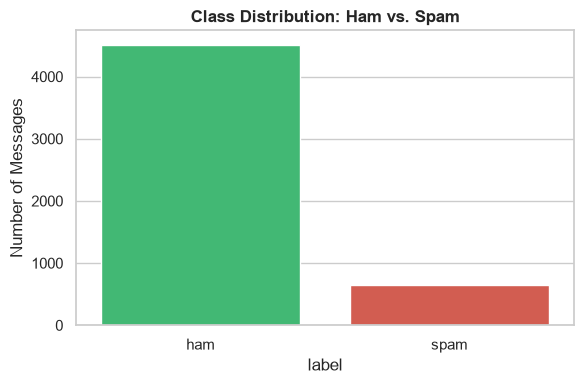

In [18]:
#Step 2: Data Loading & Class Distribution Inspection
# Load dataset
df = pd.read_csv("spam.csv", sep='\t', header=None, names=['label', 'message'])

# Deduplicate
print("Initial records:", len(df))
df.drop_duplicates(inplace=True)
print("Records after deduplication:", len(df))

# Map labels to binary values (ham: 0, spam: 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Distribution counts and percentages
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

dist_summary = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct.round(2)})
display(dist_summary)

# Visualizing class imbalance
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#2ecc71', '#e74c3c'], hue=class_counts.index, legend=False)
plt.title("Class Distribution: Ham vs. Spam", weight='bold')
plt.ylabel("Number of Messages")
plt.tight_layout()
plt.show()

In [19]:
#Step 3: Text Preprocessing Pipeline
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation, numbers, and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize and filter stopwords + apply stemming
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

df['cleaned_message'] = df['message'].apply(preprocess_text)
df[['message', 'cleaned_message']].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazi avail bugi great world buff...
1,Ok lar... Joking wif u oni...,lar joke wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win cup final tkt may tex...
3,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


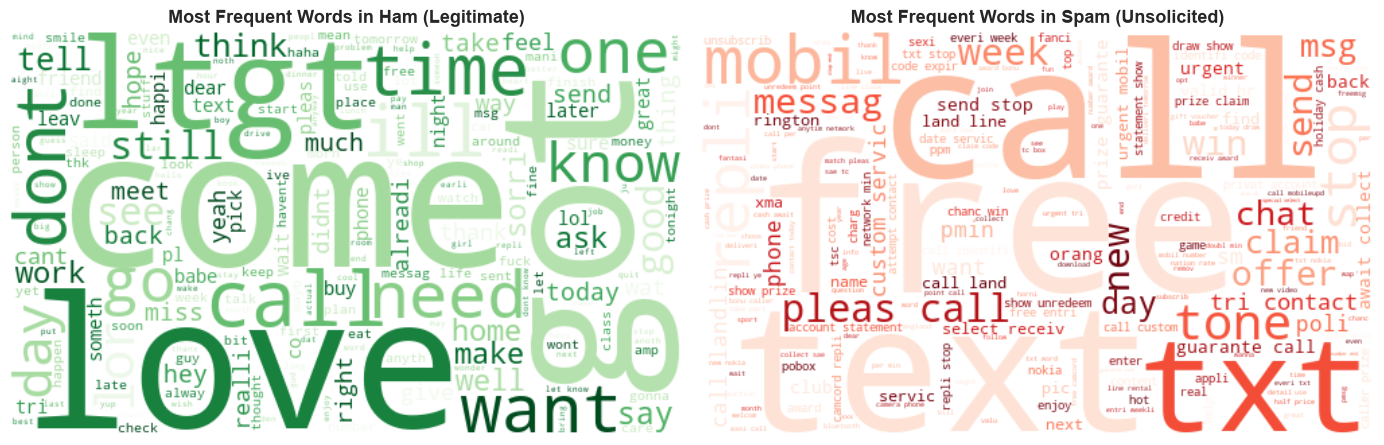

In [20]:
#Step 4: (Bonus) WordCloud Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# WordCloud for Ham
ham_words = " ".join(df[df['label'] == 'ham']['cleaned_message'])
wordcloud_ham = WordCloud(width=500, height=300, background_color='white', colormap='Greens').generate(ham_words)
axes[0].imshow(wordcloud_ham, interpolation='bilinear')
axes[0].set_title("Most Frequent Words in Ham (Legitimate)", fontsize=13, weight='bold')
axes[0].axis('off')

# WordCloud for Spam
spam_words = " ".join(df[df['label'] == 'spam']['cleaned_message'])
wordcloud_spam = WordCloud(width=500, height=300, background_color='white', colormap='Reds').generate(spam_words)
axes[1].imshow(wordcloud_spam, interpolation='bilinear')
axes[1].set_title("Most Frequent Words in Spam (Unsolicited)", fontsize=13, weight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [21]:
#Step 5: Feature Extraction via TF-IDF Vectorization
X = df['cleaned_message']
y = df['label_num']

# Stratified 80/20 train/test split to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Extract top 3,000 TF-IDF features
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Testing feature matrix shape:  {X_test_tfidf.shape}")

Training feature matrix shape: (4135, 3000)
Testing feature matrix shape:  (1034, 3000)


In [22]:
#Step 6: Classifier Training & Comparative Evaluation
models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "Linear SVM": SVC(kernel='linear', C=1.0, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4)
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9739,0.9483,0.8397,0.8907
1,Linear SVM,0.9768,0.9573,0.8550,0.9032


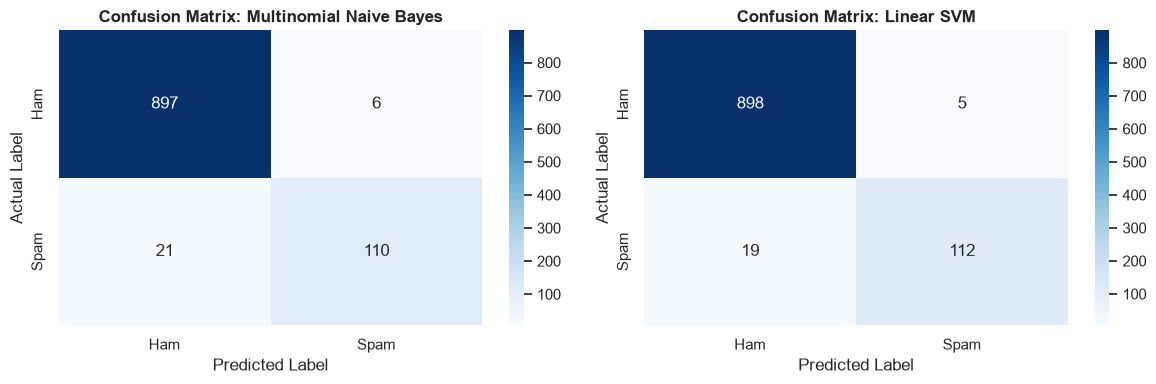

In [23]:
#Step 7: Confusion Matrix Evaluation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[idx].set_title(f"Confusion Matrix: {name}", weight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [24]:
## Step 8: Error Analysis — Precision vs. Recall in Spam Detection

### Why is Recall Critical, and Where Does the Trade-off Lie?
* **The Importance of Recall:** Recall measures the proportion of actual spam messages successfully caught by the filter ($\frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$). A high recall rate ensures malicious phishing, scams, and malware links are intercepted before reaching the user's primary inbox.
* **The Precision Priority (The Cost of False Positives):** In real-world email filtering, **Precision is typically prioritized over Recall** ($\frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$):
  * **False Negative (Spam in Inbox):** A minor nuisance; the user simply deletes the unwanted email.
  * **False Positive (Legitimate Email in Spam):** A critical failure; an urgent job interview invitation, password reset token, or official communication is misdirected to the junk folder and missed entirely.
* **Conclusion:** While maintaining strong recall is necessary for inbox cleanliness, spam filters must optimize for near-perfect precision to ensure legitimate messages are never flagged as spam.

SyntaxError: invalid syntax (859823915.py, line 4)

In [ ]:
##Step 9: Inference on Unseen Samples
# Unseen sample messages
sample_messages = [
    "URGENT: Claim your free 1000 cash voucher today. Call 0800123456 immediately to register!",
    "Hey Shahzad, are you free this afternoon to discuss the machine learning assignment?",
    "Your package delivery attempt failed. Update your tracking credentials at http://bit.ly/fake-link now."
]

# Apply identical preprocessing pipeline
cleaned_samples = [preprocess_text(msg) for msg in sample_messages]
sample_vectors = tfidf.transform(cleaned_samples)

# Predict using the Linear SVM classifier
best_clf = models["Linear SVM"]
predictions = best_clf.predict(sample_vectors)

# Display results
for original, pred in zip(sample_messages, predictions):
    status = "🚨 SPAM" if pred == 1 else "✅ HAM"
    print(f"{status}: \"{original}\"\n")

🚨 SPAM: "URGENT: Claim your free 1000 cash voucher today. Call 0800123456 immediately to register!"

✅ HAM: "Hey Shahzad, are you free this afternoon to discuss the machine learning assignment?"

🚨 SPAM: "Your package delivery attempt failed. Update your tracking credentials at http://bit.ly/fake-link now."

